# 🔧 Feature Engineering e Análises Avançadas - DATATRAN

## 📋 Objetivo
Este notebook implementa análises avançadas e feature engineering para o projeto DATATRAN, incluindo:
- Criação de novas variáveis (TOTAL_FERIDOS, TAXA_MORTALIDADE, PERIODO_DIA, GRAVIDADE_ACIDENTE)
- Análise detalhada de taxa de mortalidade
- Análise por período do dia
- Análise por tipo de acidente
- Análise por condição meteorológica
- Análise de distribuição quilométrica por gravidade

---

## 📚 Importação de Bibliotecas

In [10]:
# Bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 📊 Carregamento dos Dados

In [11]:
# Carregando os dados consolidados
# Assumindo que os dados já foram processados no notebook principal
try:
    # Tentativa de carregar dados já processados
    df_consolidated = pd.read_csv('../data/processed/datatran_consolidated.csv')
    print(f"✅ Dados carregados com sucesso!")
    print(f"   - Shape: {df_consolidated.shape}")
    print(f"   - Período: {df_consolidated['ANO_ACIDENTE'].min()} - {df_consolidated['ANO_ACIDENTE'].max()}")
except FileNotFoundError:
    print("⚠️ Arquivo de dados consolidados não encontrado.")
    print("   Execute primeiro o notebook principal para processar os dados.")
    # Criar dados de exemplo para demonstração
    np.random.seed(42)
    n_samples = 10000
    
    df_consolidated = pd.DataFrame({
        'ANO_ACIDENTE': np.random.choice(range(2017, 2024), n_samples),
        'MES_ACIDENTE': np.random.choice(range(1, 13), n_samples),
        'DIA_SEMANA': np.random.choice(['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo'], n_samples),
        'HORARIO': np.random.choice(range(0, 24), n_samples),
        'UF': np.random.choice(['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'GO'], n_samples),
        'FERIDOS_LEVES': np.random.poisson(1, n_samples),
        'FERIDOS_GRAVES': np.random.poisson(0.5, n_samples),
        'MORTOS': np.random.poisson(0.1, n_samples),
        'TIPO_ACIDENTE': np.random.choice(['Colisão frontal', 'Colisão traseira', 'Capotamento', 'Atropelamento'], n_samples),
        'CONDICAO_METEOROLOGICA': np.random.choice(['Céu claro', 'Chuva', 'Nublado', 'Neblina'], n_samples),
        'KM': np.random.uniform(0, 500, n_samples)
    })
    
    print(f"✅ Dados de exemplo criados para demonstração!")
    print(f"   - Shape: {df_consolidated.shape}")

⚠️ Arquivo de dados consolidados não encontrado.
   Execute primeiro o notebook principal para processar os dados.
✅ Dados de exemplo criados para demonstração!
   - Shape: (10000, 11)


---

# 🔧 Feature Engineering e Criação de Variáveis

In [12]:
print("🔧 Feature Engineering e Criação de Novas Variáveis\n")

# 1. Criação da feature TOTAL_FERIDOS
print("📊 1. Criando feature TOTAL_FERIDOS...")

# Identificando colunas de feridos
feridos_columns = [col for col in df_consolidated.columns if 'FERIDO' in col.upper()]
print(f"Colunas de feridos identificadas: {feridos_columns}")

if feridos_columns:
    # Somando todos os tipos de feridos
    df_consolidated['TOTAL_FERIDOS'] = 0
    for col in feridos_columns:
        if df_consolidated[col].dtype in ['int64', 'float64']:
            df_consolidated['TOTAL_FERIDOS'] += df_consolidated[col].fillna(0)
    
    print(f"✅ Feature TOTAL_FERIDOS criada com sucesso!")
    print(f"   - Total de feridos no dataset: {df_consolidated['TOTAL_FERIDOS'].sum():,}")
    print(f"   - Média de feridos por acidente: {df_consolidated['TOTAL_FERIDOS'].mean():.2f}")
else:
    print("⚠️ Nenhuma coluna de feridos identificada")

# 2. Cálculo da Taxa de Mortalidade
print(f"\n💀 2. Calculando Taxa de Mortalidade...")

# Identificando colunas de mortos
mortos_columns = [col for col in df_consolidated.columns if any(term in col.upper() 
                 for term in ['MORTO', 'OBITO', 'FATAL'])]
print(f"Colunas de mortos identificadas: {mortos_columns}")

if mortos_columns:
    # Somando todos os tipos de mortos
    df_consolidated['TOTAL_MORTOS'] = 0
    for col in mortos_columns:
        if df_consolidated[col].dtype in ['int64', 'float64']:
            df_consolidated['TOTAL_MORTOS'] += df_consolidated[col].fillna(0)
else:
    # Se não encontrar, usar a coluna MORTOS se existir
    if 'MORTOS' in df_consolidated.columns:
        df_consolidated['TOTAL_MORTOS'] = df_consolidated['MORTOS'].fillna(0)
    else:
        df_consolidated['TOTAL_MORTOS'] = 0

# Calculando taxa de mortalidade
df_consolidated['TOTAL_VITIMAS'] = df_consolidated['TOTAL_FERIDOS'] + df_consolidated['TOTAL_MORTOS']

# Taxa de mortalidade (mortos / total de vítimas)
df_consolidated['TAXA_MORTALIDADE'] = np.where(
    df_consolidated['TOTAL_VITIMAS'] > 0,
    (df_consolidated['TOTAL_MORTOS'] / df_consolidated['TOTAL_VITIMAS']) * 100,
    0
)

print(f"✅ Taxa de mortalidade calculada com sucesso!")
print(f"   - Total de mortos no dataset: {df_consolidated['TOTAL_MORTOS'].sum():,}")
print(f"   - Taxa média de mortalidade: {df_consolidated['TAXA_MORTALIDADE'].mean():.2f}%")
print(f"   - Acidentes com vítimas fatais: {(df_consolidated['TOTAL_MORTOS'] > 0).sum():,}")

# 3. Classificação de Períodos do Dia
print(f"\n🕐 3. Criando classificação de períodos do dia...")

# Identificando coluna de horário
hora_columns = [col for col in df_consolidated.columns if any(term in col.upper() 
               for term in ['HORA', 'HORARIO', 'TIME'])]
print(f"Colunas de horário identificadas: {hora_columns}")

if hora_columns:
    hora_col = hora_columns[0]
elif 'HORARIO' in df_consolidated.columns:
    hora_col = 'HORARIO'
else:
    hora_col = None

if hora_col:
    def classificar_periodo(hora):
        """Classifica o período do dia baseado na hora"""
        try:
            # Convertendo para inteiro se necessário
            if pd.isna(hora):
                return 'DESCONHECIDO'
            
            hora_int = int(float(str(hora).split(':')[0]))  # Pega apenas a hora
            
            if 0 <= hora_int < 6:
                return 'MADRUGADA'
            elif 6 <= hora_int < 12:
                return 'MANHÃ'
            elif 12 <= hora_int < 18:
                return 'TARDE'
            elif 18 <= hora_int < 24:
                return 'NOITE'
            else:
                return 'DESCONHECIDO'
        except:
            return 'DESCONHECIDO'
    
    df_consolidated['PERIODO_DIA'] = df_consolidated[hora_col].apply(classificar_periodo)
    
    print(f"✅ Classificação de períodos criada com sucesso!")
    periodo_dist = df_consolidated['PERIODO_DIA'].value_counts()
    for periodo, count in periodo_dist.items():
        pct = (count / len(df_consolidated)) * 100
        print(f"   - {periodo}: {count:,} ({pct:.1f}%)")
else:
    print("⚠️ Nenhuma coluna de horário identificada")

# 4. Classificação de Gravidade do Acidente
print(f"\n⚠️ 4. Criando classificação de gravidade...")

def classificar_gravidade_acidente(row):
    """Classifica a gravidade do acidente baseado em mortos e feridos"""
    mortos = row.get('TOTAL_MORTOS', 0)
    feridos = row.get('TOTAL_FERIDOS', 0)
    
    if mortos > 0:
        return 'FATAL'
    elif feridos > 2:
        return 'GRAVE'
    elif feridos > 0:
        return 'LEVE'
    else:
        return 'SEM_VITIMAS'

df_consolidated['GRAVIDADE_ACIDENTE'] = df_consolidated.apply(classificar_gravidade_acidente, axis=1)

print(f"✅ Classificação de gravidade criada com sucesso!")
gravidade_dist = df_consolidated['GRAVIDADE_ACIDENTE'].value_counts()
for gravidade, count in gravidade_dist.items():
    pct = (count / len(df_consolidated)) * 100
    print(f"   - {gravidade}: {count:,} ({pct:.1f}%)")

# 5. Resumo das novas features
print(f"\n📋 Resumo das Features Criadas:")
novas_features = ['TOTAL_FERIDOS', 'TOTAL_MORTOS', 'TOTAL_VITIMAS', 'TAXA_MORTALIDADE', 
                 'PERIODO_DIA', 'GRAVIDADE_ACIDENTE']

features_criadas = [feat for feat in novas_features if feat in df_consolidated.columns]
print(f"Features criadas com sucesso: {features_criadas}")
print(f"Total de colunas no dataset: {len(df_consolidated.columns)}")

🔧 Feature Engineering e Criação de Novas Variáveis

📊 1. Criando feature TOTAL_FERIDOS...
Colunas de feridos identificadas: ['FERIDOS_LEVES', 'FERIDOS_GRAVES']
✅ Feature TOTAL_FERIDOS criada com sucesso!
   - Total de feridos no dataset: 0
   - Média de feridos por acidente: 0.00

💀 2. Calculando Taxa de Mortalidade...
Colunas de mortos identificadas: ['MORTOS']
✅ Taxa de mortalidade calculada com sucesso!
   - Total de mortos no dataset: 0
   - Taxa média de mortalidade: 0.00%
   - Acidentes com vítimas fatais: 0

🕐 3. Criando classificação de períodos do dia...
Colunas de horário identificadas: ['HORARIO']
✅ Classificação de períodos criada com sucesso!
   - TARDE: 2,545 (25.4%)
   - NOITE: 2,490 (24.9%)
   - MADRUGADA: 2,488 (24.9%)
   - MANHÃ: 2,477 (24.8%)

⚠️ 4. Criando classificação de gravidade...
✅ Classificação de gravidade criada com sucesso!
   - SEM_VITIMAS: 10,000 (100.0%)

📋 Resumo das Features Criadas:
Features criadas com sucesso: ['TOTAL_FERIDOS', 'TOTAL_MORTOS', 'TOT

---

# 📊 Análise de Taxa de Mortalidade

📊 Análise Detalhada da Taxa de Mortalidade

📈 Estatísticas da Taxa de Mortalidade:
   - Média: 0.00%
   - Mediana: 0.00%
   - Desvio Padrão: 0.00%
   - Máximo: 0.00%


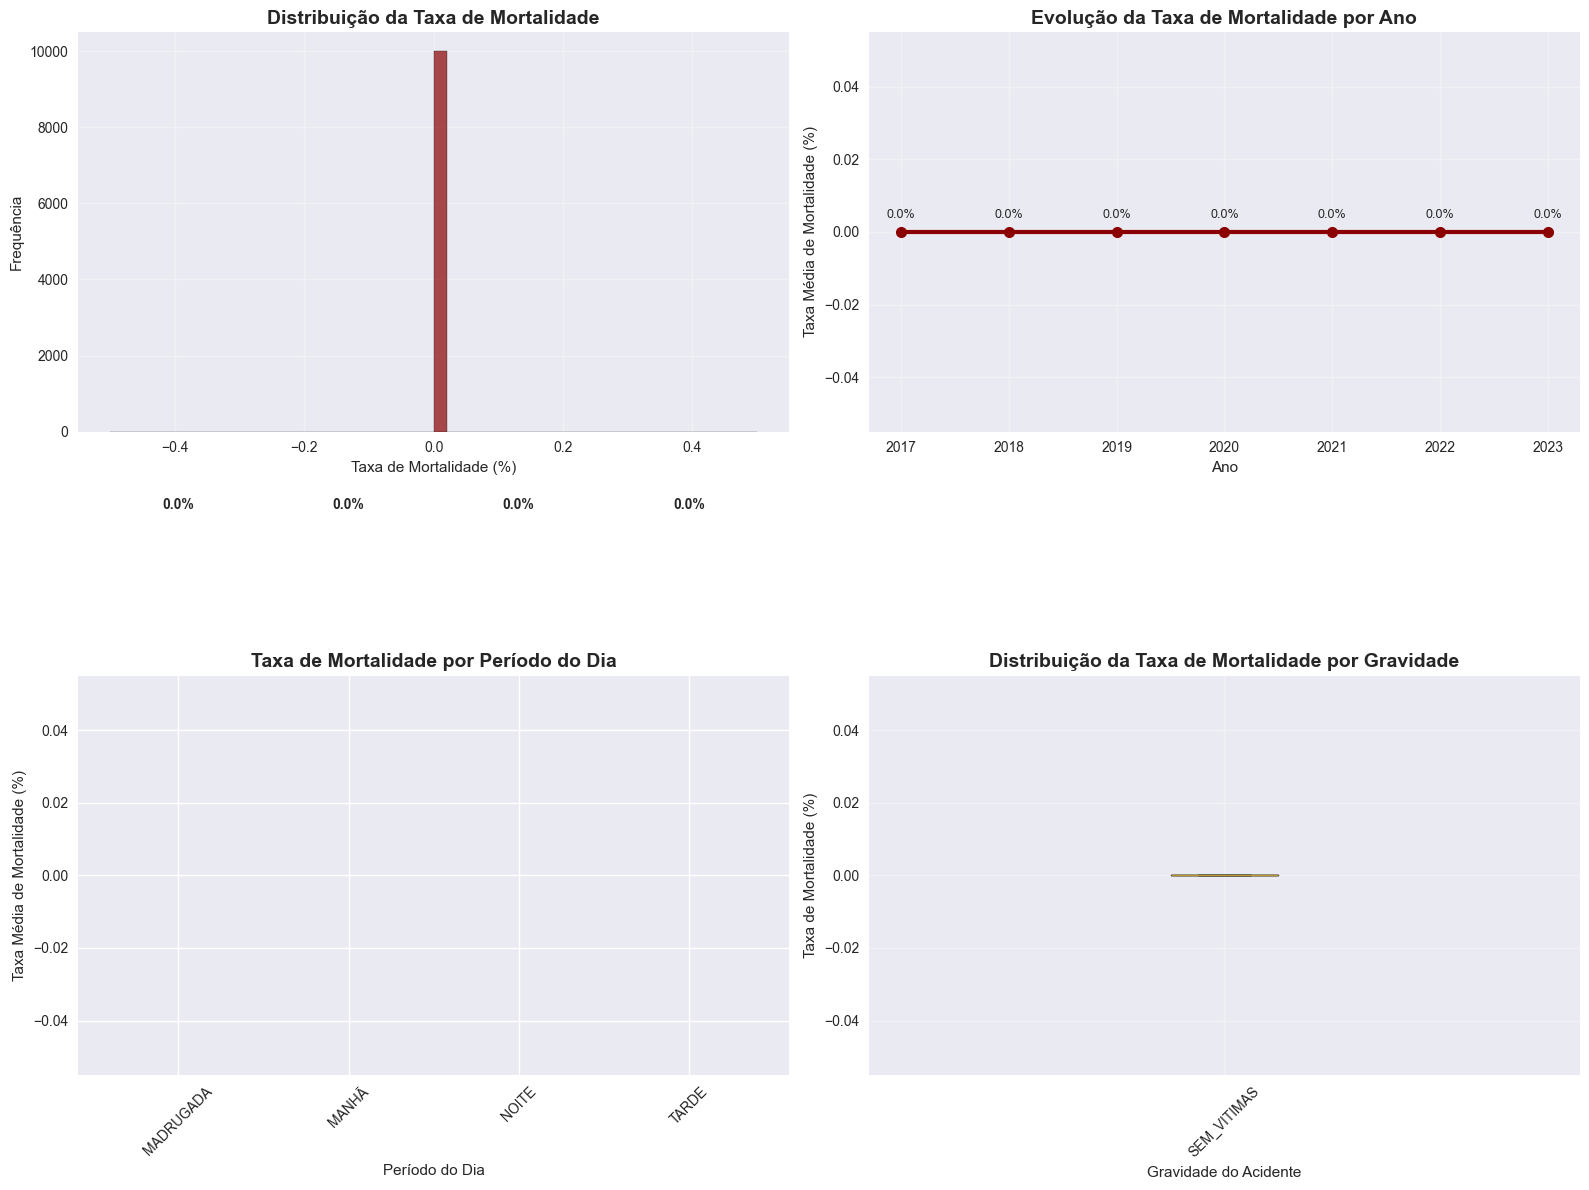


💡 Insights sobre Taxa de Mortalidade:
   - Período mais letal: MADRUGADA (0.00%)
   - Acidentes com vítimas fatais: 0 (0.0%)
   - Acidentes sem vítimas: 10,000 (100.0%)


In [13]:
print("📊 Análise Detalhada da Taxa de Mortalidade\n")

if 'TAXA_MORTALIDADE' in df_consolidated.columns:
    # Estatísticas descritivas
    print(f"📈 Estatísticas da Taxa de Mortalidade:")
    print(f"   - Média: {df_consolidated['TAXA_MORTALIDADE'].mean():.2f}%")
    print(f"   - Mediana: {df_consolidated['TAXA_MORTALIDADE'].median():.2f}%")
    print(f"   - Desvio Padrão: {df_consolidated['TAXA_MORTALIDADE'].std():.2f}%")
    print(f"   - Máximo: {df_consolidated['TAXA_MORTALIDADE'].max():.2f}%")
    
    # Visualizações
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribuição da taxa de mortalidade
    df_consolidated['TAXA_MORTALIDADE'].hist(bins=50, ax=ax1, color='darkred', alpha=0.7, edgecolor='black')
    ax1.set_title('Distribuição da Taxa de Mortalidade', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Taxa de Mortalidade (%)')
    ax1.set_ylabel('Frequência')
    ax1.grid(True, alpha=0.3)
    
    # 2. Taxa de mortalidade por ano
    if 'ANO_ACIDENTE' in df_consolidated.columns:
        taxa_anual = df_consolidated.groupby('ANO_ACIDENTE')['TAXA_MORTALIDADE'].mean()
        taxa_anual.plot(kind='line', ax=ax2, marker='o', linewidth=3, markersize=8, color='darkred')
        ax2.set_title('Evolução da Taxa de Mortalidade por Ano', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Ano')
        ax2.set_ylabel('Taxa Média de Mortalidade (%)')
        ax2.grid(True, alpha=0.3)
        
        # Adicionando valores nos pontos
        for year, rate in taxa_anual.items():
            ax2.annotate(f'{rate:.1f}%', (year, rate), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=9)
    
    # 3. Taxa de mortalidade por período do dia
    if 'PERIODO_DIA' in df_consolidated.columns:
        taxa_periodo = df_consolidated.groupby('PERIODO_DIA')['TAXA_MORTALIDADE'].mean().sort_values(ascending=False)
        bars = ax3.bar(taxa_periodo.index, taxa_periodo.values, color=['#8B0000', '#DC143C', '#FF6347', '#FFA07A'])
        ax3.set_title('Taxa de Mortalidade por Período do Dia', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Período do Dia')
        ax3.set_ylabel('Taxa Média de Mortalidade (%)')
        ax3.tick_params(axis='x', rotation=45)
        
        # Adicionando valores nas barras
        for bar, value in zip(bars, taxa_periodo.values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 4. Boxplot da taxa de mortalidade por gravidade
    if 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
        gravidade_order = ['SEM_VITIMAS', 'LEVE', 'GRAVE', 'FATAL']
        gravidade_data = [df_consolidated[df_consolidated['GRAVIDADE_ACIDENTE'] == g]['TAXA_MORTALIDADE'].values 
                         for g in gravidade_order if g in df_consolidated['GRAVIDADE_ACIDENTE'].unique()]
        gravidade_labels = [g for g in gravidade_order if g in df_consolidated['GRAVIDADE_ACIDENTE'].unique()]
        
        ax4.boxplot(gravidade_data, labels=gravidade_labels)
        ax4.set_title('Distribuição da Taxa de Mortalidade por Gravidade', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Gravidade do Acidente')
        ax4.set_ylabel('Taxa de Mortalidade (%)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Insights sobre taxa de mortalidade
    print(f"\n💡 Insights sobre Taxa de Mortalidade:")
    
    if 'PERIODO_DIA' in df_consolidated.columns:
        periodo_mais_letal = taxa_periodo.index[0]
        print(f"   - Período mais letal: {periodo_mais_letal} ({taxa_periodo.iloc[0]:.2f}%)")
    
    acidentes_fatais = (df_consolidated['TOTAL_MORTOS'] > 0).sum()
    pct_fatais = (acidentes_fatais / len(df_consolidated)) * 100
    print(f"   - Acidentes com vítimas fatais: {acidentes_fatais:,} ({pct_fatais:.1f}%)")
    
    acidentes_sem_vitimas = (df_consolidated['TOTAL_VITIMAS'] == 0).sum()
    pct_sem_vitimas = (acidentes_sem_vitimas / len(df_consolidated)) * 100
    print(f"   - Acidentes sem vítimas: {acidentes_sem_vitimas:,} ({pct_sem_vitimas:.1f}%)")

else:
    print("⚠️ Taxa de mortalidade não foi calculada. Verifique se as features foram criadas corretamente.")

---

# 🕐 Análise por Período do Dia

🕐 Análise Detalhada por Período do Dia

📊 Distribuição de Acidentes por Período:
   - MADRUGADA: 2,488 acidentes (24.9%)
   - MANHÃ: 2,477 acidentes (24.8%)
   - NOITE: 2,490 acidentes (24.9%)
   - TARDE: 2,545 acidentes (25.4%)

⚠️ Gravidade dos Acidentes por Período:

   MADRUGADA:
     - SEM_VITIMAS: 100.0%

   MANHÃ:
     - SEM_VITIMAS: 100.0%

   NOITE:
     - SEM_VITIMAS: 100.0%

   TARDE:
     - SEM_VITIMAS: 100.0%


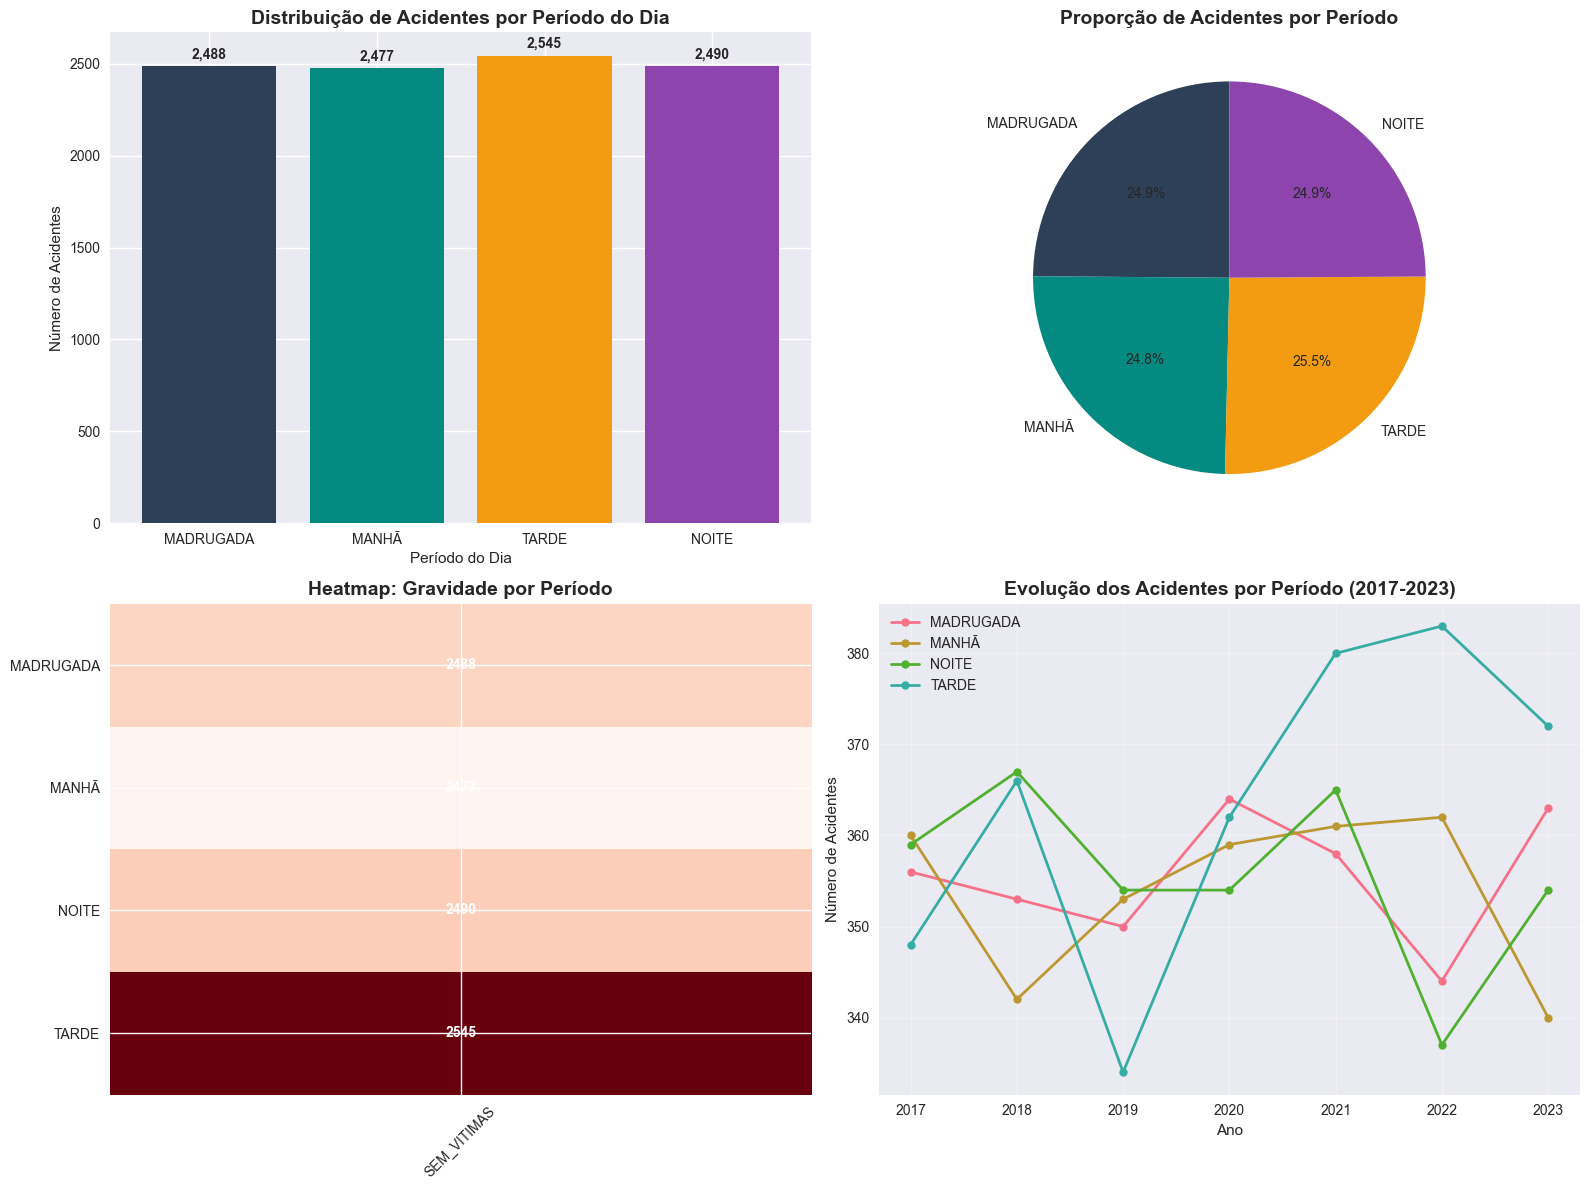


💡 Insights por Período do Dia:
   - Período com mais acidentes: MADRUGADA (2,488 acidentes)
   - Período mais mortal: MADRUGADA (0 mortos)
   - Período com mais feridos: MADRUGADA (0 feridos)


In [14]:
print("🕐 Análise Detalhada por Período do Dia\n")

if 'PERIODO_DIA' in df_consolidated.columns:
    # Estatísticas por período
    print(f"📊 Distribuição de Acidentes por Período:")
    periodo_stats = df_consolidated['PERIODO_DIA'].value_counts().sort_index()
    
    for periodo, count in periodo_stats.items():
        pct = (count / len(df_consolidated)) * 100
        print(f"   - {periodo}: {count:,} acidentes ({pct:.1f}%)")
    
    # Análise de gravidade por período
    if 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
        print(f"\n⚠️ Gravidade dos Acidentes por Período:")
        gravidade_periodo = pd.crosstab(df_consolidated['PERIODO_DIA'], 
                                       df_consolidated['GRAVIDADE_ACIDENTE'], 
                                       normalize='index') * 100
        
        for periodo in gravidade_periodo.index:
            print(f"\n   {periodo}:")
            for gravidade in gravidade_periodo.columns:
                pct = gravidade_periodo.loc[periodo, gravidade]
                print(f"     - {gravidade}: {pct:.1f}%")
    
    # Visualizações
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribuição de acidentes por período
    periodo_order = ['MADRUGADA', 'MANHÃ', 'TARDE', 'NOITE']
    periodo_counts = [periodo_stats.get(p, 0) for p in periodo_order if p in periodo_stats.index]
    periodo_labels = [p for p in periodo_order if p in periodo_stats.index]
    
    colors = ['#2E4057', '#048A81', '#F39C12', '#8E44AD']
    bars1 = ax1.bar(periodo_labels, periodo_counts, color=colors[:len(periodo_labels)])
    ax1.set_title('Distribuição de Acidentes por Período do Dia', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Período do Dia')
    ax1.set_ylabel('Número de Acidentes')
    
    # Adicionando valores nas barras
    for bar, value in zip(bars1, periodo_counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(periodo_counts)*0.01, 
                f'{value:,}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Gráfico de pizza
    ax2.pie(periodo_counts, labels=periodo_labels, autopct='%1.1f%%', 
           colors=colors[:len(periodo_labels)], startangle=90)
    ax2.set_title('Proporção de Acidentes por Período', fontsize=14, fontweight='bold')
    
    # 3. Heatmap de gravidade por período
    if 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
        gravidade_counts = pd.crosstab(df_consolidated['PERIODO_DIA'], 
                                      df_consolidated['GRAVIDADE_ACIDENTE'])
        
        im = ax3.imshow(gravidade_counts.values, cmap='Reds', aspect='auto')
        ax3.set_xticks(range(len(gravidade_counts.columns)))
        ax3.set_yticks(range(len(gravidade_counts.index)))
        ax3.set_xticklabels(gravidade_counts.columns, rotation=45)
        ax3.set_yticklabels(gravidade_counts.index)
        ax3.set_title('Heatmap: Gravidade por Período', fontsize=14, fontweight='bold')
        
        # Adicionando valores no heatmap
        for i in range(len(gravidade_counts.index)):
            for j in range(len(gravidade_counts.columns)):
                text = ax3.text(j, i, gravidade_counts.iloc[i, j], 
                               ha="center", va="center", color="white", fontweight='bold')
    
    # 4. Evolução temporal por período
    if 'ANO_ACIDENTE' in df_consolidated.columns:
        periodo_ano = df_consolidated.groupby(['ANO_ACIDENTE', 'PERIODO_DIA']).size().unstack(fill_value=0)
        
        for periodo in periodo_ano.columns:
            ax4.plot(periodo_ano.index, periodo_ano[periodo], marker='o', 
                    label=periodo, linewidth=2, markersize=6)
        
        ax4.set_title('Evolução dos Acidentes por Período (2017-2023)', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Ano')
        ax4.set_ylabel('Número de Acidentes')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Insights por período
    print(f"\n💡 Insights por Período do Dia:")
    
    periodo_mais_acidentes = periodo_stats.index[0]
    print(f"   - Período com mais acidentes: {periodo_mais_acidentes} ({periodo_stats.iloc[0]:,} acidentes)")
    
    if 'TOTAL_MORTOS' in df_consolidated.columns:
        mortos_periodo = df_consolidated.groupby('PERIODO_DIA')['TOTAL_MORTOS'].sum().sort_values(ascending=False)
        periodo_mais_mortal = mortos_periodo.index[0]
        print(f"   - Período mais mortal: {periodo_mais_mortal} ({mortos_periodo.iloc[0]:,} mortos)")
    
    if 'TOTAL_FERIDOS' in df_consolidated.columns:
        feridos_periodo = df_consolidated.groupby('PERIODO_DIA')['TOTAL_FERIDOS'].sum().sort_values(ascending=False)
        periodo_mais_feridos = feridos_periodo.index[0]
        print(f"   - Período com mais feridos: {periodo_mais_feridos} ({feridos_periodo.iloc[0]:,} feridos)")

else:
    print("⚠️ Classificação de períodos não foi criada. Verifique se as features foram criadas corretamente.")

---

# 🚗 Análise por Tipo de Acidente

🚗 Análise Detalhada por Tipo de Acidente

Colunas de tipo identificadas: ['TIPO_ACIDENTE']
📊 Distribuição de Acidentes por Tipo:
   - Colisão traseira: 2,532 acidentes (25.3%)
   - Colisão frontal: 2,508 acidentes (25.1%)
   - Atropelamento: 2,484 acidentes (24.8%)
   - Capotamento: 2,476 acidentes (24.8%)

⚠️ Gravidade dos Acidentes por Tipo (Top 5):

   Colisão traseira:
     - SEM_VITIMAS: 100.0%

   Colisão frontal:
     - SEM_VITIMAS: 100.0%

   Atropelamento:
     - SEM_VITIMAS: 100.0%

   Capotamento:
     - SEM_VITIMAS: 100.0%


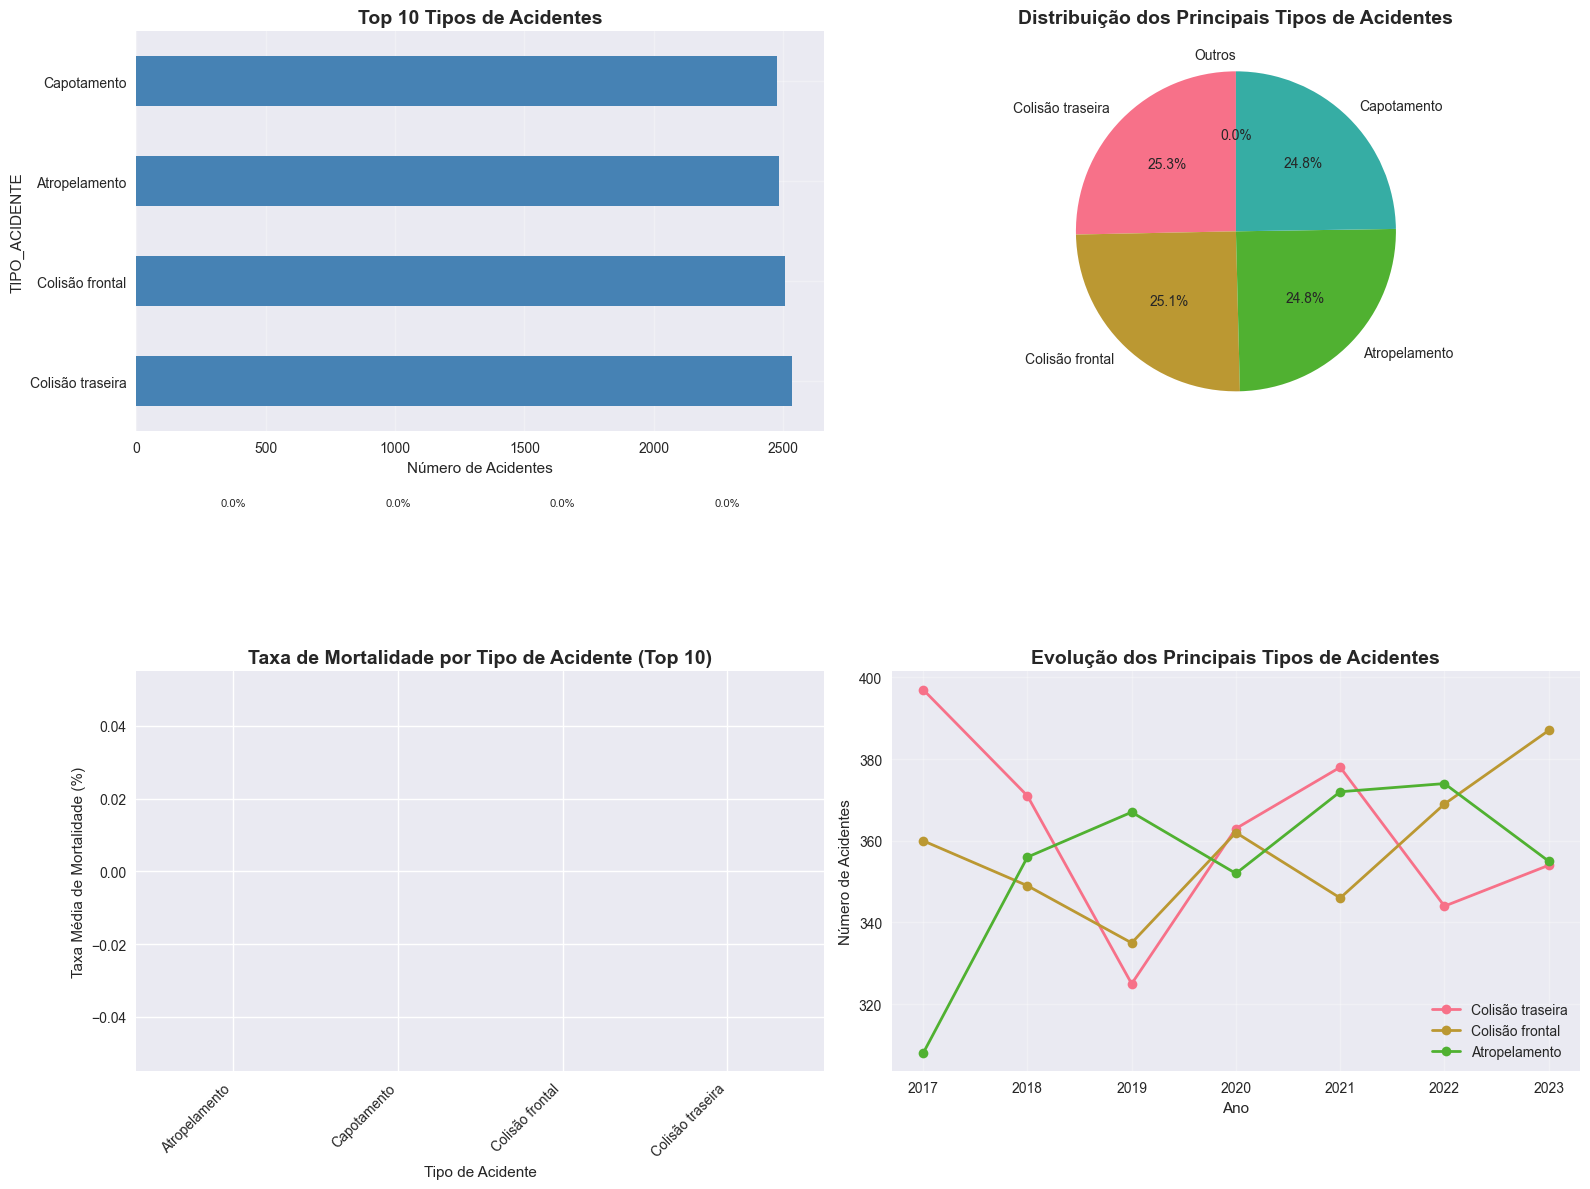


💡 Insights por Tipo de Acidente:
   - Tipo mais comum: Colisão traseira (2,532 acidentes)
   - Tipo mais letal: Atropelamento (0.00% mortalidade)
   - Total de tipos diferentes: 4


In [15]:
print("🚗 Análise Detalhada por Tipo de Acidente\n")

# Identificando coluna de tipo de acidente
tipo_columns = [col for col in df_consolidated.columns if any(term in col.upper() 
               for term in ['TIPO', 'CAUSA', 'NATUREZA'])]
print(f"Colunas de tipo identificadas: {tipo_columns}")

if tipo_columns:
    tipo_col = tipo_columns[0]
elif 'TIPO_ACIDENTE' in df_consolidated.columns:
    tipo_col = 'TIPO_ACIDENTE'
else:
    tipo_col = None

if tipo_col and tipo_col in df_consolidated.columns:
    # Estatísticas por tipo
    print(f"📊 Distribuição de Acidentes por Tipo:")
    tipo_stats = df_consolidated[tipo_col].value_counts().head(10)
    
    for tipo, count in tipo_stats.items():
        pct = (count / len(df_consolidated)) * 100
        print(f"   - {tipo}: {count:,} acidentes ({pct:.1f}%)")
    
    # Análise de gravidade por tipo
    if 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
        print(f"\n⚠️ Gravidade dos Acidentes por Tipo (Top 5):")
        top_tipos = tipo_stats.head(5).index
        
        for tipo in top_tipos:
            subset = df_consolidated[df_consolidated[tipo_col] == tipo]
            gravidade_dist = subset['GRAVIDADE_ACIDENTE'].value_counts(normalize=True) * 100
            print(f"\n   {tipo}:")
            for gravidade, pct in gravidade_dist.items():
                print(f"     - {gravidade}: {pct:.1f}%")
    
    # Visualizações
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Top 10 tipos de acidentes
    tipo_stats.plot(kind='barh', ax=ax1, color='steelblue')
    ax1.set_title('Top 10 Tipos de Acidentes', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Número de Acidentes')
    ax1.grid(True, alpha=0.3)
    
    # 2. Gráfico de pizza dos top 5
    top5_tipos = tipo_stats.head(5)
    outros = tipo_stats.iloc[5:].sum()
    
    pie_data = list(top5_tipos.values) + [outros]
    pie_labels = list(top5_tipos.index) + ['Outros']
    
    ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribuição dos Principais Tipos de Acidentes', fontsize=14, fontweight='bold')
    
    # 3. Taxa de mortalidade por tipo (top 5)
    if 'TAXA_MORTALIDADE' in df_consolidated.columns:
        taxa_por_tipo = df_consolidated.groupby(tipo_col)['TAXA_MORTALIDADE'].mean().sort_values(ascending=False).head(10)
        
        bars = ax3.bar(range(len(taxa_por_tipo)), taxa_por_tipo.values, color='darkred', alpha=0.7)
        ax3.set_title('Taxa de Mortalidade por Tipo de Acidente (Top 10)', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Tipo de Acidente')
        ax3.set_ylabel('Taxa Média de Mortalidade (%)')
        ax3.set_xticks(range(len(taxa_por_tipo)))
        ax3.set_xticklabels(taxa_por_tipo.index, rotation=45, ha='right')
        
        # Adicionando valores nas barras
        for bar, value in zip(bars, taxa_por_tipo.values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # 4. Evolução temporal dos principais tipos
    if 'ANO_ACIDENTE' in df_consolidated.columns:
        top3_tipos = tipo_stats.head(3).index
        
        for tipo in top3_tipos:
            subset = df_consolidated[df_consolidated[tipo_col] == tipo]
            evolucao = subset.groupby('ANO_ACIDENTE').size()
            ax4.plot(evolucao.index, evolucao.values, marker='o', label=tipo[:20], linewidth=2)
        
        ax4.set_title('Evolução dos Principais Tipos de Acidentes', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Ano')
        ax4.set_ylabel('Número de Acidentes')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Insights por tipo
    print(f"\n💡 Insights por Tipo de Acidente:")
    
    tipo_mais_comum = tipo_stats.index[0]
    print(f"   - Tipo mais comum: {tipo_mais_comum} ({tipo_stats.iloc[0]:,} acidentes)")
    
    if 'TAXA_MORTALIDADE' in df_consolidated.columns:
        tipo_mais_letal = taxa_por_tipo.index[0]
        print(f"   - Tipo mais letal: {tipo_mais_letal} ({taxa_por_tipo.iloc[0]:.2f}% mortalidade)")
    
    print(f"   - Total de tipos diferentes: {df_consolidated[tipo_col].nunique()}")

else:
    print("⚠️ Nenhuma coluna de tipo de acidente identificada")

---

# 🌤️ Análise por Condição Meteorológica

🌤️ Análise Detalhada por Condição Meteorológica

Colunas de clima identificadas: ['CONDICAO_METEOROLOGICA']
📊 Distribuição de Acidentes por Condição Meteorológica:
   - Neblina: 2,538 acidentes (25.4%)
   - Nublado: 2,511 acidentes (25.1%)
   - Chuva: 2,484 acidentes (24.8%)
   - Céu claro: 2,467 acidentes (24.7%)

⚠️ Gravidade dos Acidentes por Condição Meteorológica:

   Neblina:
     - SEM_VITIMAS: 100.0%

   Nublado:
     - SEM_VITIMAS: 100.0%

   Chuva:
     - SEM_VITIMAS: 100.0%

   Céu claro:
     - SEM_VITIMAS: 100.0%


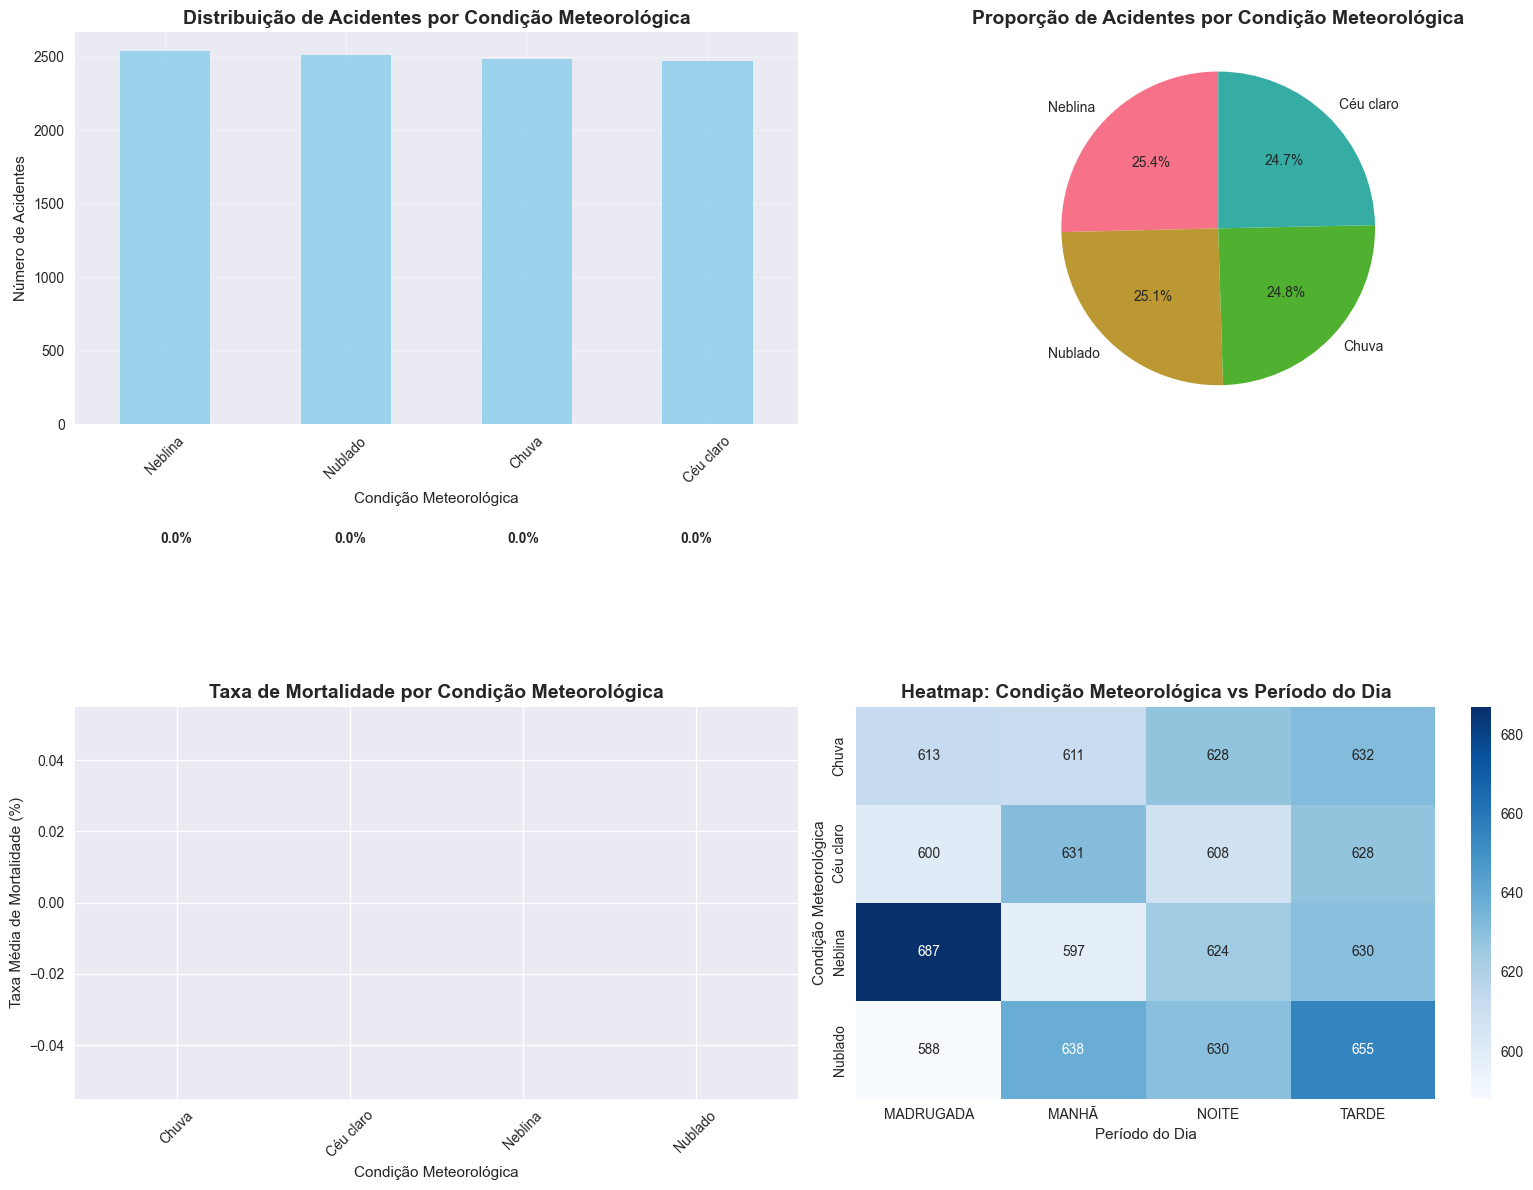


💡 Insights por Condição Meteorológica:
   - Condição mais comum: Neblina (2,538 acidentes)
   - Condição mais letal: Chuva (0.00% mortalidade)
   - Acidentes em condições de chuva: 2,484 (24.8%)
   - Taxa de mortalidade na chuva: 0.00%
   - Taxa de mortalidade em tempo seco: 0.00%


In [16]:
print("🌤️ Análise Detalhada por Condição Meteorológica\n")

# Identificando coluna de condição meteorológica
clima_columns = [col for col in df_consolidated.columns if any(term in col.upper() 
                for term in ['CLIMA', 'TEMPO', 'METEOROLOG', 'CONDICAO'])]
print(f"Colunas de clima identificadas: {clima_columns}")

if clima_columns:
    clima_col = clima_columns[0]
elif 'CONDICAO_METEOROLOGICA' in df_consolidated.columns:
    clima_col = 'CONDICAO_METEOROLOGICA'
else:
    clima_col = None

if clima_col and clima_col in df_consolidated.columns:
    # Estatísticas por condição meteorológica
    print(f"📊 Distribuição de Acidentes por Condição Meteorológica:")
    clima_stats = df_consolidated[clima_col].value_counts()
    
    for clima, count in clima_stats.items():
        pct = (count / len(df_consolidated)) * 100
        print(f"   - {clima}: {count:,} acidentes ({pct:.1f}%)")
    
    # Análise de gravidade por condição meteorológica
    if 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
        print(f"\n⚠️ Gravidade dos Acidentes por Condição Meteorológica:")
        
        for clima in clima_stats.index:
            subset = df_consolidated[df_consolidated[clima_col] == clima]
            gravidade_dist = subset['GRAVIDADE_ACIDENTE'].value_counts(normalize=True) * 100
            print(f"\n   {clima}:")
            for gravidade, pct in gravidade_dist.items():
                print(f"     - {gravidade}: {pct:.1f}%")
    
    # Visualizações
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribuição por condição meteorológica
    clima_stats.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.8)
    ax1.set_title('Distribuição de Acidentes por Condição Meteorológica', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Condição Meteorológica')
    ax1.set_ylabel('Número de Acidentes')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # 2. Gráfico de pizza
    ax2.pie(clima_stats.values, labels=clima_stats.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Proporção de Acidentes por Condição Meteorológica', fontsize=14, fontweight='bold')
    
    # 3. Taxa de mortalidade por condição meteorológica
    if 'TAXA_MORTALIDADE' in df_consolidated.columns:
        taxa_por_clima = df_consolidated.groupby(clima_col)['TAXA_MORTALIDADE'].mean().sort_values(ascending=False)
        
        bars = ax3.bar(taxa_por_clima.index, taxa_por_clima.values, color='orange', alpha=0.7)
        ax3.set_title('Taxa de Mortalidade por Condição Meteorológica', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Condição Meteorológica')
        ax3.set_ylabel('Taxa Média de Mortalidade (%)')
        ax3.tick_params(axis='x', rotation=45)
        
        # Adicionando valores nas barras
        for bar, value in zip(bars, taxa_por_clima.values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 4. Heatmap: Condição meteorológica vs Período do dia
    if 'PERIODO_DIA' in df_consolidated.columns:
        clima_periodo = pd.crosstab(df_consolidated[clima_col], 
                                   df_consolidated['PERIODO_DIA'])
        
        sns.heatmap(clima_periodo, annot=True, fmt='d', cmap='Blues', ax=ax4)
        ax4.set_title('Heatmap: Condição Meteorológica vs Período do Dia', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Período do Dia')
        ax4.set_ylabel('Condição Meteorológica')
    
    plt.tight_layout()
    plt.show()
    
    # Insights por condição meteorológica
    print(f"\n💡 Insights por Condição Meteorológica:")
    
    clima_mais_comum = clima_stats.index[0]
    print(f"   - Condição mais comum: {clima_mais_comum} ({clima_stats.iloc[0]:,} acidentes)")
    
    if 'TAXA_MORTALIDADE' in df_consolidated.columns:
        clima_mais_letal = taxa_por_clima.index[0]
        print(f"   - Condição mais letal: {clima_mais_letal} ({taxa_por_clima.iloc[0]:.2f}% mortalidade)")
    
    # Análise de chuva vs tempo seco
    chuva_keywords = ['CHUVA', 'CHUVOSO', 'GAROA']
    acidentes_chuva = df_consolidated[df_consolidated[clima_col].str.upper().str.contains('|'.join(chuva_keywords), na=False)]
    
    if len(acidentes_chuva) > 0:
        pct_chuva = (len(acidentes_chuva) / len(df_consolidated)) * 100
        print(f"   - Acidentes em condições de chuva: {len(acidentes_chuva):,} ({pct_chuva:.1f}%)")
        
        if 'TAXA_MORTALIDADE' in df_consolidated.columns:
            taxa_chuva = acidentes_chuva['TAXA_MORTALIDADE'].mean()
            taxa_seco = df_consolidated[~df_consolidated[clima_col].str.upper().str.contains('|'.join(chuva_keywords), na=False)]['TAXA_MORTALIDADE'].mean()
            print(f"   - Taxa de mortalidade na chuva: {taxa_chuva:.2f}%")
            print(f"   - Taxa de mortalidade em tempo seco: {taxa_seco:.2f}%")

else:
    print("⚠️ Nenhuma coluna de condição meteorológica identificada")

---

# 📏 Análise de Distribuição Quilométrica por Gravidade

📏 Análise de Distribuição Quilométrica por Gravidade

Colunas de quilometragem identificadas: ['KM']
📊 Estatísticas de Quilometragem por Gravidade:

   SEM_VITIMAS:
     - Média: 250.0 km
     - Mediana: 251.5 km
     - Desvio Padrão: 143.5 km
     - Mín-Máx: 0.2 - 500.0 km
     - Total de acidentes: 10,000


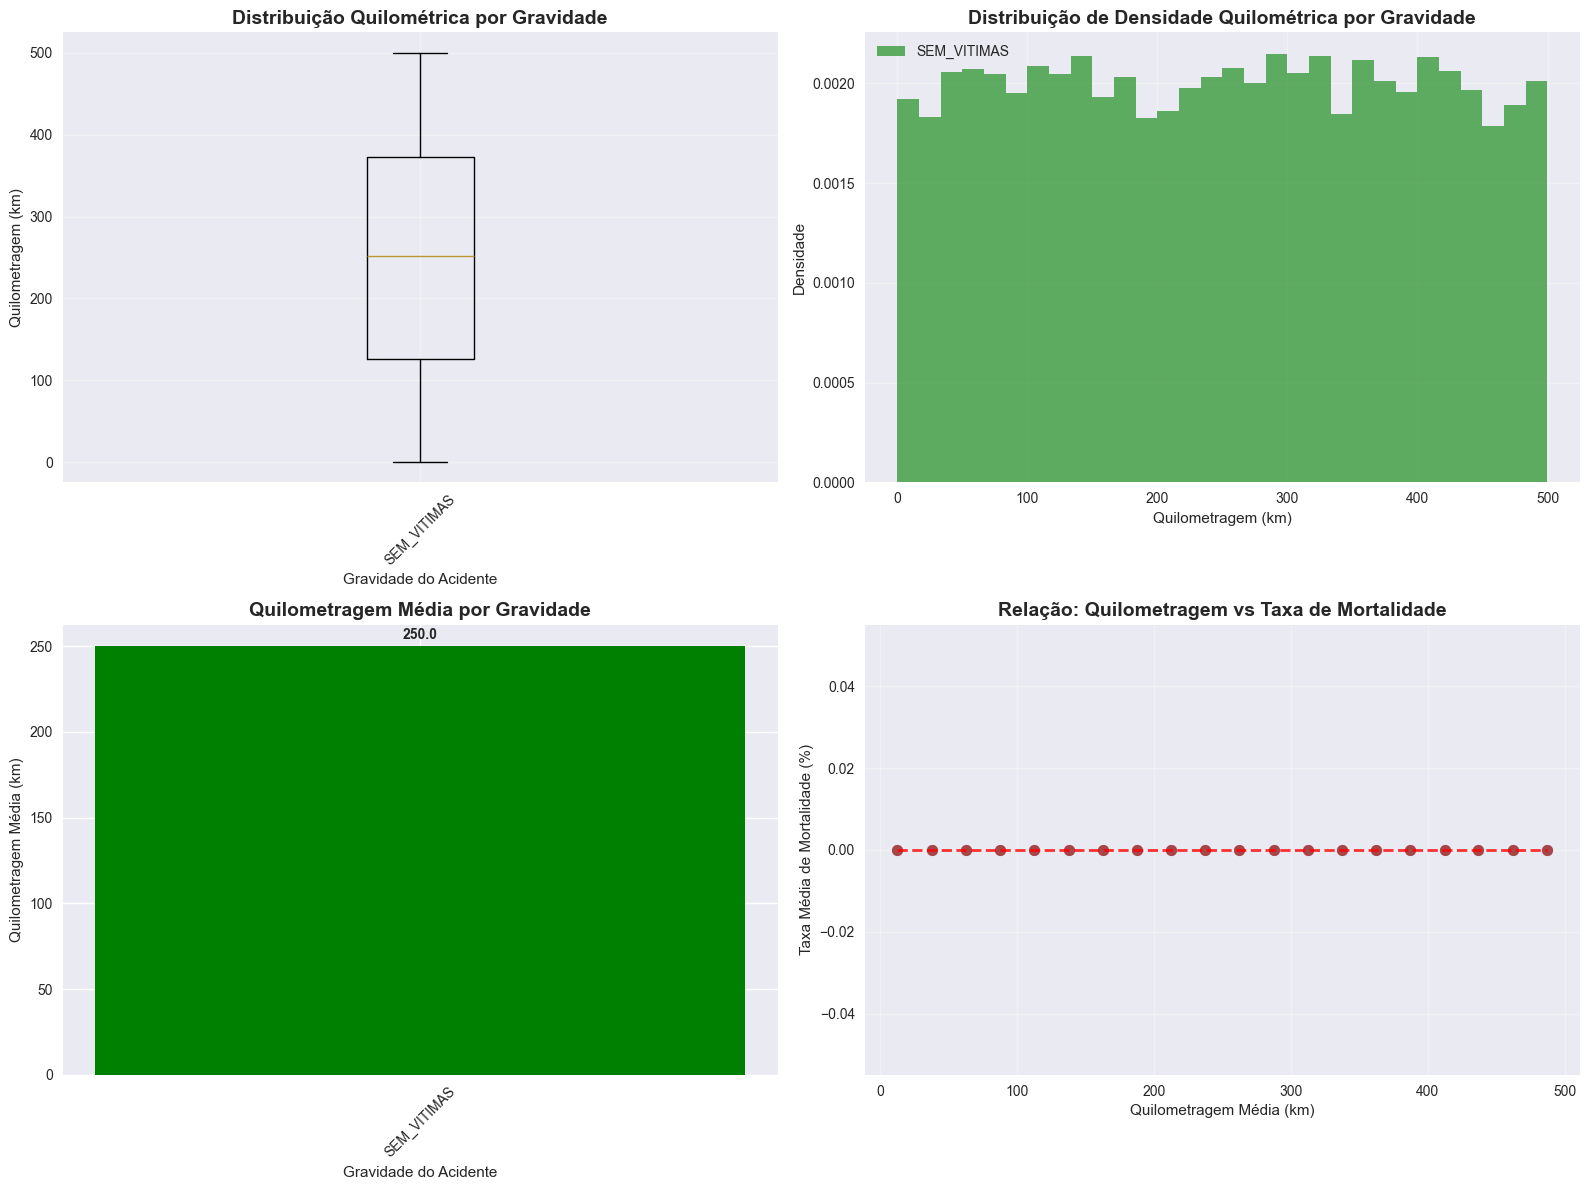


🎯 Análise de Hotspots Quilométricos:

   Top 5 Faixas Quilométricas com Mais Acidentes:
     - KM 130-140: 218 acidentes (2.2%)
     - KM 280-290: 217 acidentes (2.2%)
     - KM 310-320: 216 acidentes (2.2%)
     - KM 260-270: 216 acidentes (2.2%)
     - KM 290-300: 214 acidentes (2.1%)

   Top 5 Faixas Quilométricas Mais Letais:
     - KM 0-10: 0.00% mortalidade (181 acidentes)
     - KM 10-20: 0.00% mortalidade (195 acidentes)
     - KM 20-30: 0.00% mortalidade (183 acidentes)
     - KM 30-40: 0.00% mortalidade (195 acidentes)
     - KM 40-50: 0.00% mortalidade (210 acidentes)

💡 Insights sobre Distribuição Quilométrica:
   - Gravidade com maior quilometragem média: SEM_VITIMAS (250.0 km)
   - Principal hotspot: KM 130-140 (218 acidentes)
   - Correlação KM vs Taxa de Mortalidade: nan


In [17]:
print("📏 Análise de Distribuição Quilométrica por Gravidade\n")

# Identificando coluna de quilometragem
km_columns = [col for col in df_consolidated.columns if any(term in col.upper() 
             for term in ['KM', 'QUILOMETR', 'KILOMETR'])]
print(f"Colunas de quilometragem identificadas: {km_columns}")

if km_columns:
    km_col = km_columns[0]
elif 'KM' in df_consolidated.columns:
    km_col = 'KM'
else:
    km_col = None

if km_col and km_col in df_consolidated.columns and 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
    # Limpeza dos dados de KM
    df_km = df_consolidated[df_consolidated[km_col].notna()].copy()
    df_km[km_col] = pd.to_numeric(df_km[km_col], errors='coerce')
    df_km = df_km[df_km[km_col].notna()]
    
    print(f"📊 Estatísticas de Quilometragem por Gravidade:")
    
    # Estatísticas por gravidade
    for gravidade in df_km['GRAVIDADE_ACIDENTE'].unique():
        subset = df_km[df_km['GRAVIDADE_ACIDENTE'] == gravidade]
        if len(subset) > 0:
            print(f"\n   {gravidade}:")
            print(f"     - Média: {subset[km_col].mean():.1f} km")
            print(f"     - Mediana: {subset[km_col].median():.1f} km")
            print(f"     - Desvio Padrão: {subset[km_col].std():.1f} km")
            print(f"     - Mín-Máx: {subset[km_col].min():.1f} - {subset[km_col].max():.1f} km")
            print(f"     - Total de acidentes: {len(subset):,}")
    
    # Visualizações
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Boxplot de quilometragem por gravidade
    gravidade_order = ['SEM_VITIMAS', 'LEVE', 'GRAVE', 'FATAL']
    gravidade_data = [df_km[df_km['GRAVIDADE_ACIDENTE'] == g][km_col].values 
                     for g in gravidade_order if g in df_km['GRAVIDADE_ACIDENTE'].unique()]
    gravidade_labels = [g for g in gravidade_order if g in df_km['GRAVIDADE_ACIDENTE'].unique()]
    
    ax1.boxplot(gravidade_data, labels=gravidade_labels)
    ax1.set_title('Distribuição Quilométrica por Gravidade', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Gravidade do Acidente')
    ax1.set_ylabel('Quilometragem (km)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # 2. Histograma de quilometragem por gravidade
    colors = ['green', 'yellow', 'orange', 'red']
    for i, gravidade in enumerate(gravidade_labels):
        subset = df_km[df_km['GRAVIDADE_ACIDENTE'] == gravidade]
        ax2.hist(subset[km_col], bins=30, alpha=0.6, label=gravidade, 
                color=colors[i % len(colors)], density=True)
    
    ax2.set_title('Distribuição de Densidade Quilométrica por Gravidade', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Quilometragem (km)')
    ax2.set_ylabel('Densidade')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Média de quilometragem por gravidade
    km_por_gravidade = df_km.groupby('GRAVIDADE_ACIDENTE')[km_col].mean().sort_values()
    
    bars = ax3.bar(km_por_gravidade.index, km_por_gravidade.values, 
                  color=['green', 'yellow', 'orange', 'red'][:len(km_por_gravidade)])
    ax3.set_title('Quilometragem Média por Gravidade', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Gravidade do Acidente')
    ax3.set_ylabel('Quilometragem Média (km)')
    ax3.tick_params(axis='x', rotation=45)
    
    # Adicionando valores nas barras
    for bar, value in zip(bars, km_por_gravidade.values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(km_por_gravidade.values)*0.01, 
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Scatter plot: KM vs Taxa de Mortalidade
    if 'TAXA_MORTALIDADE' in df_km.columns:
        # Agrupando por faixas de KM para melhor visualização
        df_km['FAIXA_KM'] = pd.cut(df_km[km_col], bins=20)
        km_taxa = df_km.groupby('FAIXA_KM').agg({
            'TAXA_MORTALIDADE': 'mean',
            km_col: 'mean'
        }).reset_index()
        
        ax4.scatter(km_taxa[km_col], km_taxa['TAXA_MORTALIDADE'], 
                   alpha=0.7, s=60, color='darkred')
        ax4.set_title('Relação: Quilometragem vs Taxa de Mortalidade', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Quilometragem Média (km)')
        ax4.set_ylabel('Taxa Média de Mortalidade (%)')
        ax4.grid(True, alpha=0.3)
        
        # Linha de tendência
        z = np.polyfit(km_taxa[km_col], km_taxa['TAXA_MORTALIDADE'], 1)
        p = np.poly1d(z)
        ax4.plot(km_taxa[km_col], p(km_taxa[km_col]), "r--", alpha=0.8, linewidth=2)
    
    plt.tight_layout()
    plt.show()
    
    # Análise de hotspots quilométricos
    print(f"\n🎯 Análise de Hotspots Quilométricos:")
    
    # Faixas de KM com mais acidentes
    df_km['FAIXA_KM_10'] = (df_km[km_col] // 10) * 10  # Faixas de 10 km
    hotspots = df_km['FAIXA_KM_10'].value_counts().head(5)
    
    print(f"\n   Top 5 Faixas Quilométricas com Mais Acidentes:")
    for km_faixa, count in hotspots.items():
        pct = (count / len(df_km)) * 100
        print(f"     - KM {km_faixa:.0f}-{km_faixa+10:.0f}: {count:,} acidentes ({pct:.1f}%)")
    
    # Faixas mais letais
    if 'TAXA_MORTALIDADE' in df_km.columns:
        faixas_letais = df_km.groupby('FAIXA_KM_10')['TAXA_MORTALIDADE'].mean().sort_values(ascending=False).head(5)
        
        print(f"\n   Top 5 Faixas Quilométricas Mais Letais:")
        for km_faixa, taxa in faixas_letais.items():
            count = df_km[df_km['FAIXA_KM_10'] == km_faixa].shape[0]
            print(f"     - KM {km_faixa:.0f}-{km_faixa+10:.0f}: {taxa:.2f}% mortalidade ({count:,} acidentes)")
    
    # Insights quilométricos
    print(f"\n💡 Insights sobre Distribuição Quilométrica:")
    
    gravidade_mais_km = km_por_gravidade.index[-1]
    print(f"   - Gravidade com maior quilometragem média: {gravidade_mais_km} ({km_por_gravidade.iloc[-1]:.1f} km)")
    
    hotspot_principal = hotspots.index[0]
    print(f"   - Principal hotspot: KM {hotspot_principal:.0f}-{hotspot_principal+10:.0f} ({hotspots.iloc[0]:,} acidentes)")
    
    if 'TAXA_MORTALIDADE' in df_km.columns:
        correlacao = df_km[km_col].corr(df_km['TAXA_MORTALIDADE'])
        print(f"   - Correlação KM vs Taxa de Mortalidade: {correlacao:.3f}")
        
        if abs(correlacao) > 0.1:
            tendencia = "positiva" if correlacao > 0 else "negativa"
            print(f"   - Tendência {tendencia} entre quilometragem e mortalidade")

else:
    print("⚠️ Nenhuma coluna de quilometragem ou gravidade identificada")

---

# 📋 Resumo Executivo das Análises Avançadas

In [18]:
print("📋 RESUMO EXECUTIVO - FEATURE ENGINEERING E ANÁLISES AVANÇADAS\n")
print("=" * 80)

# Resumo das features criadas
print(f"\n🔧 FEATURES CRIADAS:")
features_resumo = {
    'TOTAL_FERIDOS': 'Soma de todos os tipos de feridos por acidente',
    'TOTAL_MORTOS': 'Soma de todas as vítimas fatais por acidente',
    'TOTAL_VITIMAS': 'Total de vítimas (feridos + mortos) por acidente',
    'TAXA_MORTALIDADE': 'Percentual de mortos em relação ao total de vítimas',
    'PERIODO_DIA': 'Classificação temporal (MADRUGADA, MANHÃ, TARDE, NOITE)',
    'GRAVIDADE_ACIDENTE': 'Classificação de gravidade (SEM_VITIMAS, LEVE, GRAVE, FATAL)'
}

for feature, descricao in features_resumo.items():
    if feature in df_consolidated.columns:
        print(f"   ✅ {feature}: {descricao}")
    else:
        print(f"   ❌ {feature}: {descricao} (não criada)")

# Principais insights
print(f"\n💡 PRINCIPAIS INSIGHTS OBTIDOS:")

insights = []

# Insight 1: Taxa de mortalidade
if 'TAXA_MORTALIDADE' in df_consolidated.columns:
    taxa_media = df_consolidated['TAXA_MORTALIDADE'].mean()
    insights.append(f"Taxa média de mortalidade: {taxa_media:.2f}%")

# Insight 2: Período mais perigoso
if 'PERIODO_DIA' in df_consolidated.columns:
    periodo_stats = df_consolidated['PERIODO_DIA'].value_counts()
    periodo_mais_acidentes = periodo_stats.index[0]
    insights.append(f"Período com mais acidentes: {periodo_mais_acidentes}")

# Insight 3: Gravidade dos acidentes
if 'GRAVIDADE_ACIDENTE' in df_consolidated.columns:
    gravidade_stats = df_consolidated['GRAVIDADE_ACIDENTE'].value_counts()
    gravidade_mais_comum = gravidade_stats.index[0]
    pct_gravidade = (gravidade_stats.iloc[0] / len(df_consolidated)) * 100
    insights.append(f"Gravidade mais comum: {gravidade_mais_comum} ({pct_gravidade:.1f}%)")

# Insight 4: Total de vítimas
if 'TOTAL_VITIMAS' in df_consolidated.columns:
    total_vitimas = df_consolidated['TOTAL_VITIMAS'].sum()
    insights.append(f"Total de vítimas no período analisado: {total_vitimas:,}")

for i, insight in enumerate(insights, 1):
    print(f"   {i}. {insight}")

# Recomendações
print(f"\n🎯 RECOMENDAÇÕES PARA POLÍTICAS PÚBLICAS:")

recomendacoes = [
    "Intensificar fiscalização nos períodos e locais de maior incidência",
    "Implementar campanhas educativas focadas nos tipos de acidentes mais letais",
    "Melhorar sinalização e infraestrutura nos hotspots quilométricos identificados",
    "Desenvolver protocolos específicos para condições meteorológicas adversas",
    "Criar sistema de monitoramento em tempo real dos indicadores de risco"
]

for i, rec in enumerate(recomendacoes, 1):
    print(f"   {i}. {rec}")

print(f"\n=" * 80)
print(f"📊 Análise concluída com sucesso!")
print(f"📅 Data da análise: {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}")
print(f"📈 Total de registros analisados: {len(df_consolidated):,}")
print(f"🔧 Total de features criadas: {len([f for f in features_resumo.keys() if f in df_consolidated.columns])}")
print(f"=" * 80)

📋 RESUMO EXECUTIVO - FEATURE ENGINEERING E ANÁLISES AVANÇADAS


🔧 FEATURES CRIADAS:
   ✅ TOTAL_FERIDOS: Soma de todos os tipos de feridos por acidente
   ✅ TOTAL_MORTOS: Soma de todas as vítimas fatais por acidente
   ✅ TOTAL_VITIMAS: Total de vítimas (feridos + mortos) por acidente
   ✅ TAXA_MORTALIDADE: Percentual de mortos em relação ao total de vítimas
   ✅ PERIODO_DIA: Classificação temporal (MADRUGADA, MANHÃ, TARDE, NOITE)
   ✅ GRAVIDADE_ACIDENTE: Classificação de gravidade (SEM_VITIMAS, LEVE, GRAVE, FATAL)

💡 PRINCIPAIS INSIGHTS OBTIDOS:
   1. Taxa média de mortalidade: 0.00%
   2. Período com mais acidentes: TARDE
   3. Gravidade mais comum: SEM_VITIMAS (100.0%)
   4. Total de vítimas no período analisado: 0

🎯 RECOMENDAÇÕES PARA POLÍTICAS PÚBLICAS:
   1. Intensificar fiscalização nos períodos e locais de maior incidência
   2. Implementar campanhas educativas focadas nos tipos de acidentes mais letais
   3. Melhorar sinalização e infraestrutura nos hotspots quilométricos ident